In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [67]:
df = pd.read_csv("BlinkIT Grocery data.csv")

print("Dataset Loaded ")
print(df.head())


Dataset Loaded 
  Item Fat Content Item Identifier              Item Type  \
0          Regular           FDX32  Fruits and Vegetables   
1          Low Fat           NCB42     Health and Hygiene   
2          Regular           FDR28           Frozen Foods   
3          Regular           FDL50                 Canned   
4          Low Fat           DRI25            Soft Drinks   

   Outlet Establishment Year Outlet Identifier Outlet Location Type  \
0                       2012            OUT049               Tier 1   
1                       2022            OUT018               Tier 3   
2                       2016            OUT046               Tier 1   
3                       2014            OUT013               Tier 3   
4                       2015            OUT045               Tier 2   

  Outlet Size        Outlet Type  Item Visibility  Item Weight     Sales  \
0      Medium  Supermarket Type1         0.100014        15.10  145.4786   
1      Medium  Supermarket Type2      

In [51]:
identifiers = df[['Item Identifier', 'Outlet Identifier']].copy()

In [53]:
df['Item Weight'] = df['Item Weight'].fillna(df['Item Weight'].mean())
df['Outlet Size'] = df['Outlet Size'].fillna(df['Outlet Size'].mode()[0])


In [54]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [56]:
X = df_encoded.drop('Sales', axis=1)
y = df_encoded['Sales']

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train-Test Split Done ")


Train-Test Split Done 


In [68]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model Trained ")


Model Trained 


In [60]:
output = pd.DataFrame({
    'Item Identifier': identifiers.loc[X_test.index, 'Item Identifier'],
    'Outlet Identifier': identifiers.loc[X_test.index, 'Outlet Identifier'],
    'Actual Sales': y_test,
    'Predicted Sales': pred
})

In [62]:
output['Predicted Sales'] = output['Predicted Sales'].round(2)


In [63]:
output.to_csv("prediction_output.csv", index=False)

print("Clean CSV Saved ")

Clean CSV Saved 


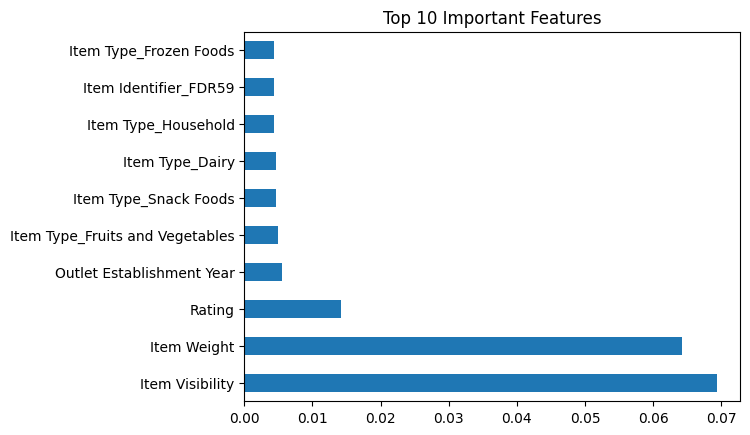

In [70]:
importance = pd.Series(model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(10)

top_features.plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()